In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# ---------- Load and preprocess image ----------
# Change 'image.jpg' to your image file path
img = cv2.imread(r"C:\Users\hp\Downloads\CV\airplane.bmp")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)

In [15]:
def my_harris_detector(gray, k=0.04, window_size=5, threshold=0.01):
    Ix = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    Iy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

    Ix2 = Ix ** 2
    Iy2 = Iy ** 2
    Ixy = Ix * Iy

    Sx2 = cv2.GaussianBlur(Ix2, (window_size, window_size), 1)
    Sy2 = cv2.GaussianBlur(Iy2, (window_size, window_size), 1)
    Sxy = cv2.GaussianBlur(Ixy, (window_size, window_size), 1)

    R = (Sx2 * Sy2 - Sxy ** 2) - k * ((Sx2 + Sy2) ** 2)

    # Normalize and threshold
    R_norm = cv2.normalize(R, None, 0, 255, cv2.NORM_MINMAX)
    R_norm = np.uint8(R_norm)
    corners = np.zeros_like(R_norm)
    corners[R_norm > 180] = 1

    # Non-maximum suppression
    corners = (R_norm == cv2.dilate(R_norm, None)) & (R_norm > 180)

    return R_norm, corners.astype(np.uint8)

In [16]:
# ---------- OpenCV Harris Implementation ----------
gray_cv = np.float32(gray)
dst = cv2.cornerHarris(gray_cv, blockSize=3, ksize=3, k=0.05)
dst = cv2.dilate(dst, None)
img_cv = img.copy()
img_cv[dst > 0.02 * dst.max()] = [0, 0, 255]

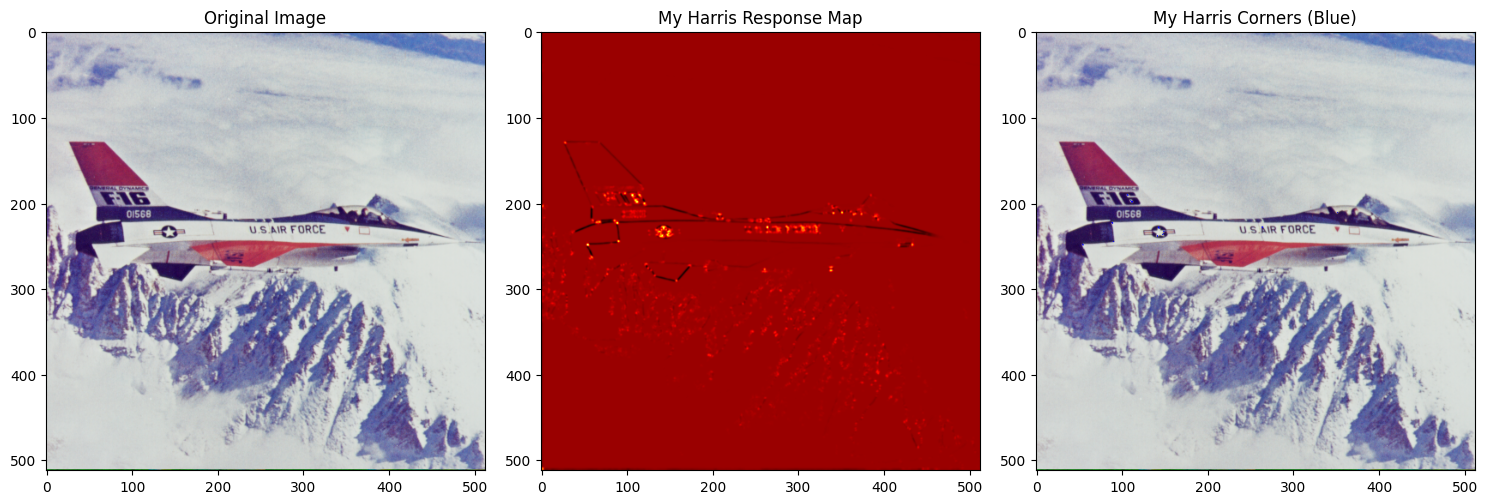

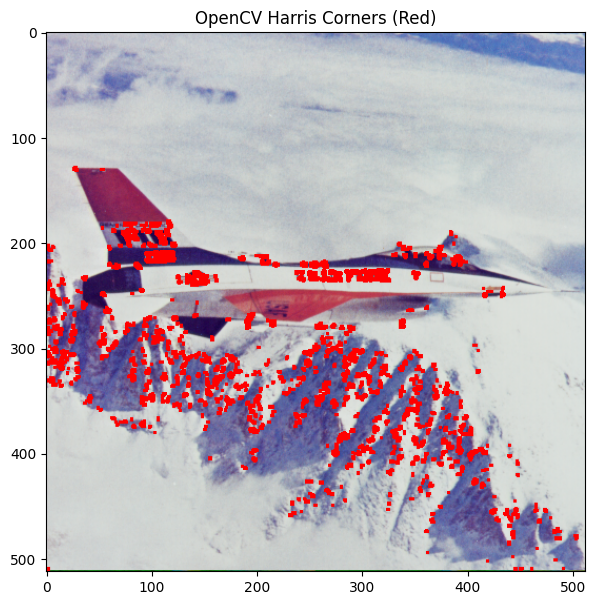

In [17]:
# ---------- Visualize Results ----------
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Image")

axes[1].imshow(R_my, cmap='hot')
axes[1].set_title("My Harris Response Map")

# Overlay corners
img_my = img.copy()
img_my[corners_my > 0.5] = [255, 0, 0]
axes[2].imshow(cv2.cvtColor(img_my, cv2.COLOR_BGR2RGB))
axes[2].set_title("My Harris Corners (Blue)")

plt.tight_layout()
plt.show()

# ---------- Show OpenCV corners for comparison ----------
plt.figure(figsize=(7,7))
plt.imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
plt.title("OpenCV Harris Corners (Red)")
plt.show()

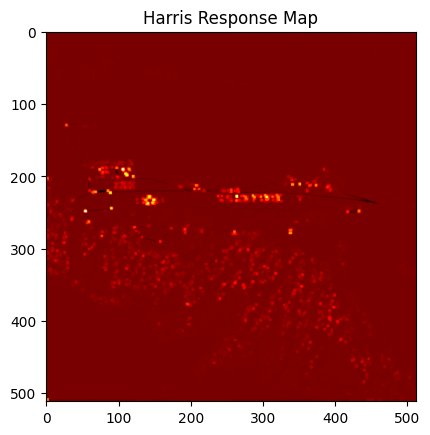

In [18]:
plt.imshow(dst, cmap='hot')
plt.title('Harris Response Map')
plt.show()

## Notes

Even though my implementation and cv2 implementation shows same response map but due a visualization issue I cannot get it to show my corners.